<a href="https://colab.research.google.com/github/MachineLearning30110/MachineLearning-Models/blob/main/Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  


In [4]:
X = df.drop("target", axis=1)
y = df["target"]

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_test.shape)

(4128, 8)


In [7]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [8]:
from sklearn.metrics import r2_score, mean_squared_error

preds = rf.predict(X_test)

print("R2:", r2_score(y_test, preds))
print("MSE:", mean_squared_error(y_test, preds))

R2: 0.8051230593157366
MSE: 0.2553684927247781


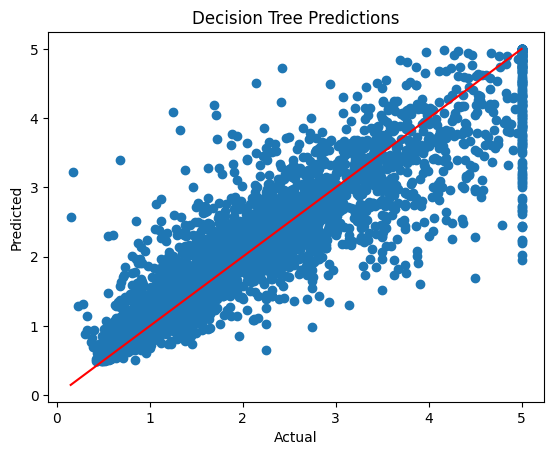

In [9]:
import matplotlib.pyplot as plt

plt.scatter(y_test, preds)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Decision Tree Predictions")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], c="red")

plt.show()

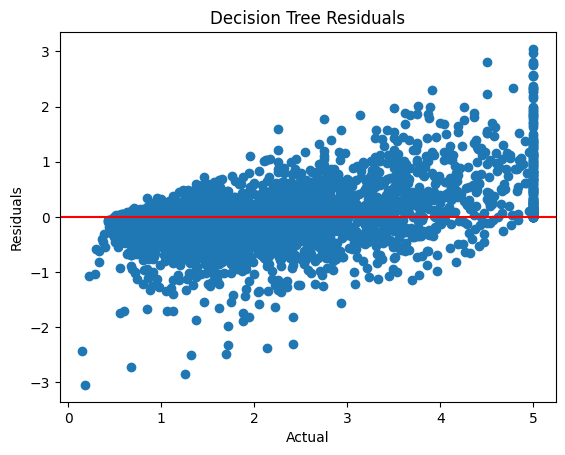

In [12]:
residuals = y_test - preds
plt.scatter(y_test, residuals)
plt.xlabel("Actual")
plt.ylabel("Residuals")
plt.axhline(y=0, color="red")
plt.title("Decision Tree Residuals")
plt.show()

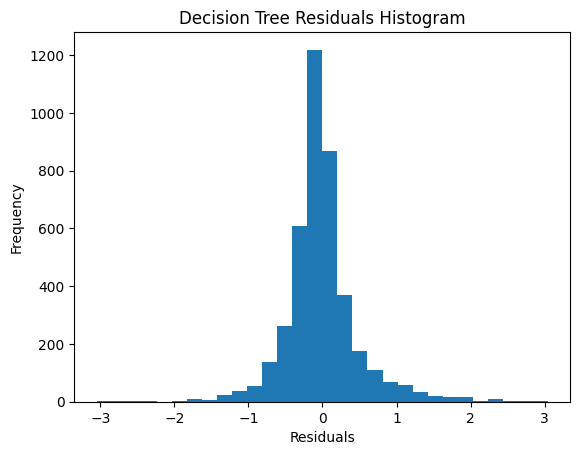

In [16]:
plt.hist(residuals, bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Decision Tree Residuals Histogram")
plt.show()

In [17]:
import pandas as pd

importances = rf.feature_importances_
features = X.columns

pd.Series(importances, index=features).sort_values(ascending=False)

,0
MedInc,0.524871
AveOccup,0.138443
Latitude,0.088936
Longitude,0.088629
HouseAge,0.054593
AveRooms,0.044272
Population,0.030650
AveBedrms,0.029606
